In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile
import os

# Replace with your actual zip file name if different
zip_path = "archive.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print(os.listdir("dataset"))

['combined_hate_speech_dataset.csv']


In [ ]:
for root, dirs, files in os.walk("dataset"):
    for file in files:
        print(os.path.join(root, file))

dataset/combined_hate_speech_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv("dataset/combined_hate_speech_dataset.csv")
df.head()

,text,hate_label,source,profanity_score,language,dataset_version,combined_date,text_length,word_count
0,Knowing ki Vikas kitna samjhata hai Priyanka a...,0,hate_speech_tsv,0,hinglish,v1.0,2025-09-11,126,25
1,I am Muhajir .. Aur mere lye sab se Pehly Paki...,0,hate_speech_tsv,0,hinglish,v1.0,2025-09-11,196,41
2,Doctor sab sahi me ke PhD (in hate politics) ...,0,hate_speech_tsv,0,hinglish,v1.0,2025-09-11,166,29
3,Poore Desh me Patel OBC me aate Hain sirf gujr...,0,hate_speech_tsv,0,hinglish,v1.0,2025-09-11,257,49
4,Sarkar banne ke bad Hindu hit me ek bhi faisla...,1,hate_speech_tsv,0,hinglish,v1.0,2025-09-11,140,25


In [ ]:
print(df.columns)
print(df["hate_label"].value_counts())

Index(['text', 'hate_label', 'source', 'profanity_score', 'language',
       'dataset_version', 'combined_date', 'text_length', 'word_count'],
      dtype='object')
hate_label
0    15825
1    13725
Name: count, dtype: int64


In [ ]:
df.rename(columns={"hate_label": "label"}, inplace=True)

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

In [ ]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [ ]:
!pip install -U transformers accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 94.2 MB/s eta 0:00:00


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=128)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
import torch

class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_encodings, train_labels)
val_dataset = Dataset(val_encodings, val_labels)

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    eval_strategy="epoch",   # ✅ NEW (correct)
    logging_steps=50,
)

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [ ]:
from transformers import Trainer

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.531197,0.555322,0.693570,0.567471,0.823856,0.432787
2,0.531798,0.610569,0.691371,0.544228,0.866348,0.396721
3,0.524771,0.542696,0.722673,0.625543,0.838848,0.498725
4,0.423525,0.648267,0.719797,0.609065,0.865191,0.469945
5,0.360541,0.716172,0.716751,0.605189,0.858194,0.467395


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=7390, training_loss=0.4811812944115418, metrics={'train_runtime': 5694.0852, 'train_samples_per_second': 20.758, 'train_steps_per_second': 1.298, 'total_flos': 7774931685888000.0, 'train_loss': 0.4811812944115418, 'epoch': 5.0})

In [ ]:
trainer.predict(val_dataset)

PredictionOutput(predictions=array([[ 0.2403724 , -0.0065365 ],
       [ 0.2403724 , -0.0065365 ],
       [ 3.2121282 , -2.8922184 ],
       ...,
       [ 3.4119897 , -3.0786848 ],
       [ 3.1216538 , -2.773944  ],
       [ 0.24037234, -0.00653648]], dtype=float32), label_ids=array([0, 0, 0, ..., 0, 0, 1]), metrics={'test_loss': 0.7161720991134644, 'test_accuracy': 0.716751269035533, 'test_f1': 0.605188679245283, 'test_precision': 0.8581939799331104, 'test_recall': 0.4673952641165756, 'test_runtime': 36.7293, 'test_samples_per_second': 160.907, 'test_steps_per_second': 10.074})

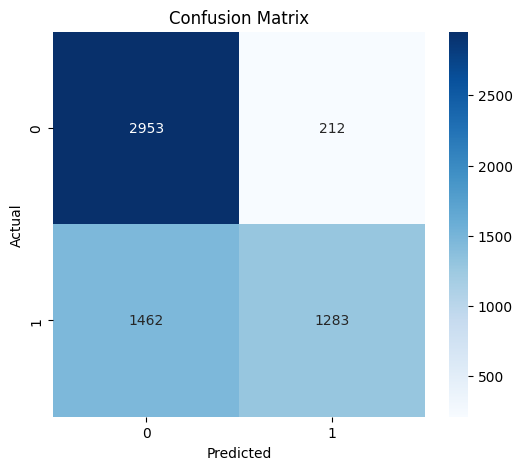

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

predictions = trainer.predict(val_dataset)

preds = np.argmax(predictions.predictions, axis=1)

cm = confusion_matrix(val_labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(val_labels, preds))

              precision    recall  f1-score   support

           0       0.67      0.93      0.78      3165
           1       0.86      0.47      0.61      2745

    accuracy                           0.72      5910
   macro avg       0.76      0.70      0.69      5910
weighted avg       0.76      0.72      0.70      5910



In [ ]:
import numpy as np

predictions = trainer.predict(val_dataset)

y_true = predictions.label_ids
logits = predictions.predictions

# Probabilities
probs = torch.nn.functional.softmax(torch.tensor(logits), dim=1).numpy()

# Predicted labels
y_pred = np.argmax(probs, axis=1)

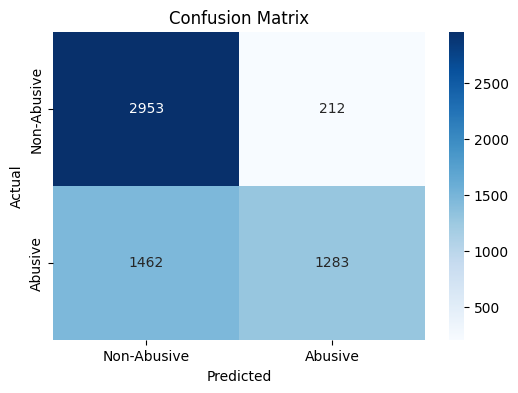

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Non-Abusive", "Abusive"],
            yticklabels=["Non-Abusive", "Abusive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

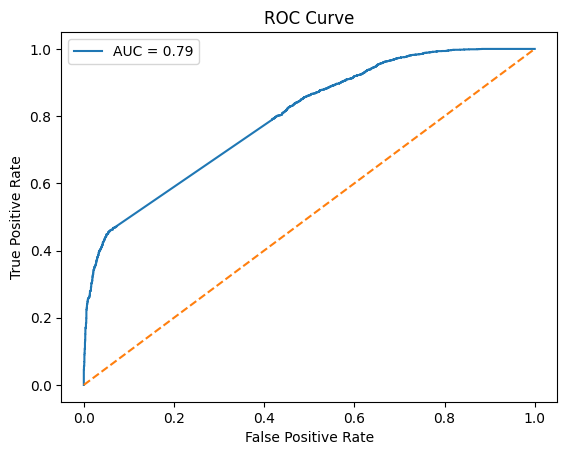

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, probs[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

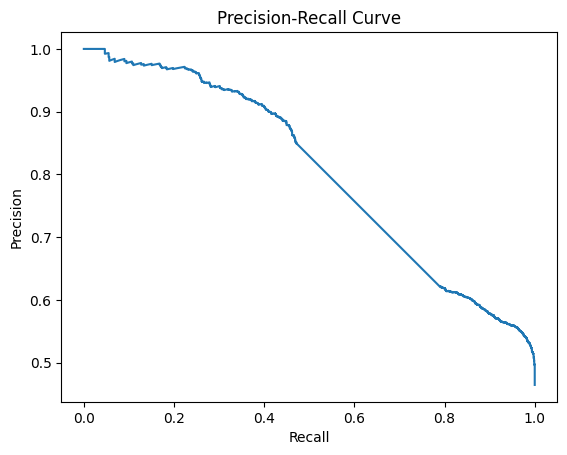

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, probs[:,1])

plt.figure()
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

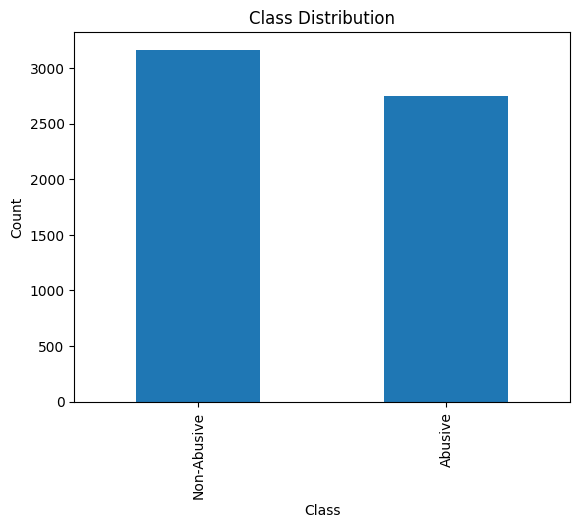

In [ ]:
import pandas as pd

df_plot = pd.DataFrame({"label": y_true})

df_plot["label"].value_counts().plot(kind='bar')

plt.xticks([0,1], ["Non-Abusive", "Abusive"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
def predict(text):
    text = clean_text(text)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k,v in inputs.items()}

    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)

    pred = torch.argmax(probs).item()
    confidence = probs[0][pred].item()

    return ("Abusive" if pred==1 else "Non-Abusive", confidence)

In [ ]:
examples = [
    "tu bahut stupid hai",
    "you are ek number ka idiot",
    "tu bahut acha hai",
    "you are a good person",
    "macha you are useless"
]

for text in examples:
    label, conf = predict(text)
    print(f"{text} → {label} ({conf:.2f})")

NameError: name 'device' is not defined

In [ ]:
import torch

def predict(text):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    text = clean_text(text)

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    # 🔥 MOVE INPUT TO GPU
    inputs = {key: val.to(device) for key, val in inputs.items()}

    # 🔥 MOVE MODEL TO GPU (important if not already)
    model.to(device)

    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)

    pred = torch.argmax(probs).item()

    return "Abusive" if pred == 1 else "Non-Abusive"

In [ ]:
print(predict("you are ek number ka idiot"))
print(predict("tu bahut nice hai"))